In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans

from scipy.cluster.hierarchy import linkage
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import fcluster

from sklearn.metrics import silhouette_score

In [13]:
df = pd.read_excel(
    r"C:\Users\NARENDRA\Downloads\Clustering  - Assignment 6\5. Clustering\EastWestAirlines.xlsx",
    sheet_name="data"
)

df.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


In [14]:
df.shape

(3999, 12)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID#                3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award?             3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB


In [16]:
df.describe()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
count,3999.000000,3.999000e+03,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000,3999.00000,3999.000000,3999.000000,3999.00000,3999.000000
mean,2014.819455,7.360133e+04,144.114529,2.059515,1.014504,1.012253,17144.846212,11.60190,460.055764,1.373593,4118.55939,0.370343
std,1160.764358,1.007757e+05,773.663804,1.376919,0.147650,0.195241,24150.967826,9.60381,1400.209171,3.793172,2065.13454,0.482957
min,1.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,2.00000,0.000000
25%,1010.500000,1.852750e+04,0.000000,1.000000,1.000000,1.000000,1250.000000,3.00000,0.000000,0.000000,2330.00000,0.000000
50%,2016.000000,4.309700e+04,0.000000,1.000000,1.000000,1.000000,7171.000000,12.00000,0.000000,0.000000,4096.00000,0.000000
75%,3020.500000,9.240400e+04,0.000000,3.000000,1.000000,1.000000,23800.500000,17.00000,311.000000,1.000000,5790.50000,1.000000
max,4021.000000,1.704838e+06,11148.000000,5.000000,3.000000,5.000000,263685.000000,86.00000,30817.000000,53.000000,8296.00000,1.000000


In [17]:
df.isnull().sum()

ID#                  0
Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0
dtype: int64

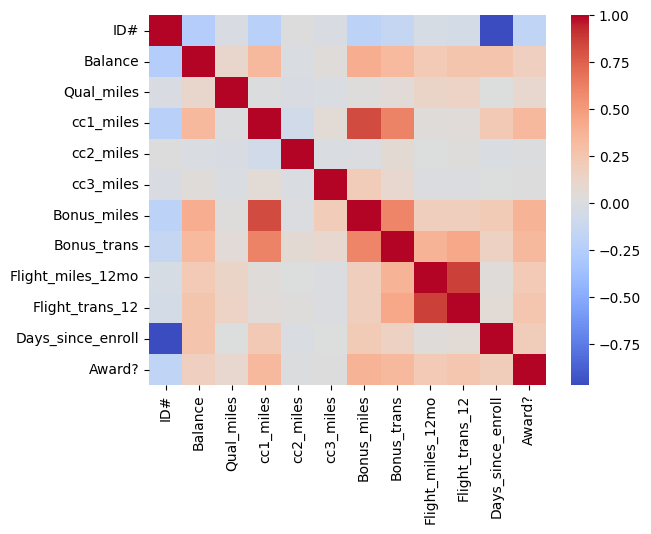

In [18]:
sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm"
)

plt.show()

In [22]:
X = df.drop("ID#", axis=1)

In [23]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [24]:
wcss = []

for i in range(1,11):

    model = KMeans(
        n_clusters=i,
        random_state=42
    )

    model.fit(X_scaled)

    wcss.append(model.inertia_)

C:\Users\NARENDRA\anaconda3\envs\AI\lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


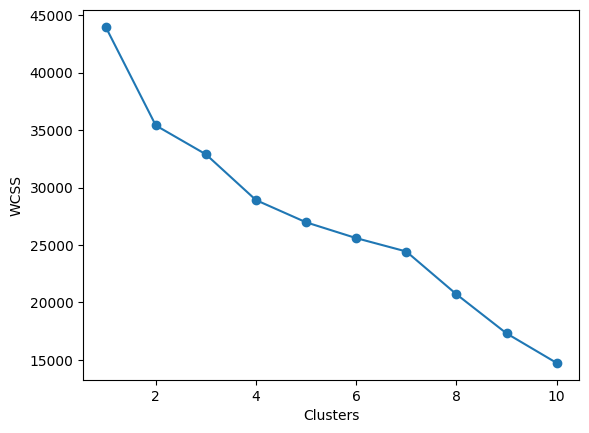

In [25]:
plt.plot(
    range(1,11),
    wcss,
    marker="o"
)

plt.xlabel("Clusters")

plt.ylabel("WCSS")

plt.show()

In [26]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

cluster_labels = kmeans.fit_predict(
    X_scaled
)

df["KMeans_Cluster"] = cluster_labels

In [27]:
df["KMeans_Cluster"].value_counts()

KMeans_Cluster
3    1186
2     989
1     841
0     839
4     144
Name: count, dtype: int64

In [28]:
silhouette_score(
    X_scaled,
    cluster_labels
)

0.2005393837499611

In [29]:
linkage_matrix = linkage(
    X_scaled,
    method="ward"
)

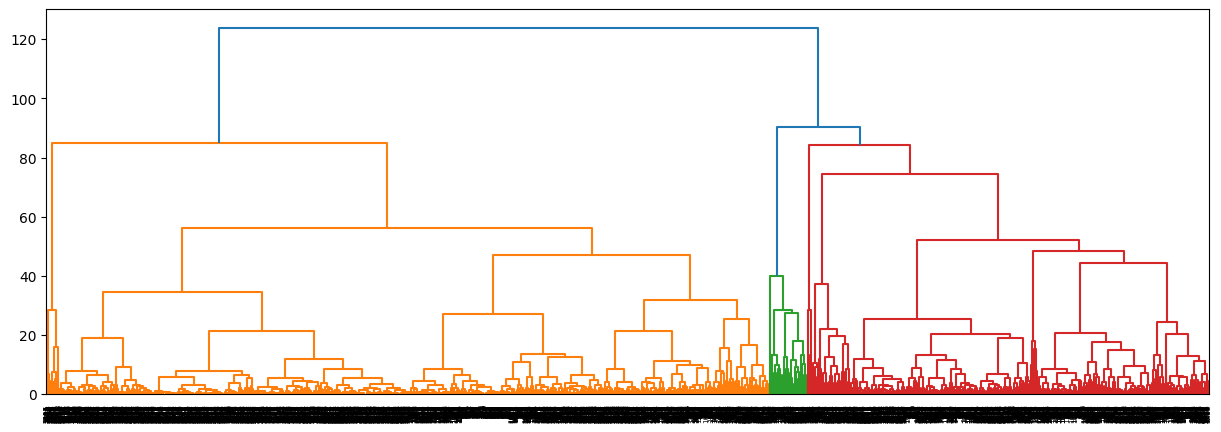

In [30]:
plt.figure(figsize=(15,5))

dendrogram(linkage_matrix)

plt.show()

In [31]:
hier_labels = fcluster(
    linkage_matrix,
    5,
    criterion="maxclust"
)

df["Hierarchical_Cluster"] = hier_labels

In [32]:
df["Hierarchical_Cluster"].value_counts()

Hierarchical_Cluster
2    2446
5    1362
3     130
1      43
4      18
Name: count, dtype: int64

In [33]:
df.groupby(
    "KMeans_Cluster"
).mean(numeric_only=True)

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?,Hierarchical_Cluster
KMeans_Cluster,,,,,,,,,,,,,
0,1945.497020,58124.779499,193.427890,1.699642,1.019070,1.000000,10816.562574,10.760429,417.281287,1.258641,4271.570918,1.000000,3.340882
1,1563.870392,139193.010702,145.376932,4.195006,1.002378,1.057075,51174.633769,20.095125,383.443520,1.166468,4938.801427,0.625446,4.948870
2,1158.110212,59918.329626,70.803842,1.495450,1.020222,1.001011,6402.407482,8.601618,177.680485,0.528817,5632.927199,0.000000,2.336704
3,3127.675379,34546.727656,93.012648,1.247049,1.011804,1.000000,4428.688027,6.623946,141.472175,0.424958,2101.258853,0.000000,2.080944
4,1770.708333,196333.680556,773.805556,2.250000,1.041667,1.000000,33783.833333,28.506944,5719.972222,16.868056,4650.562500,0.805556,3.215278


In [34]:
df.groupby(
    "Hierarchical_Cluster"
).mean(numeric_only=True)

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?,KMeans_Cluster
Hierarchical_Cluster,,,,,,,,,,,,,
1,2269.372093,68876.581395,23.255814,1.139535,2.348837,1.000000,14689.837209,17.534884,582.627907,2.209302,3968.930233,0.395349,1.837209
2,2197.204007,46329.336877,9.028618,1.244072,1.000000,1.000000,4868.112428,6.907604,214.812756,0.673753,3769.337694,0.184383,2.104661
3,1765.615385,134880.892308,393.323077,2.430769,1.000000,1.000000,36582.169231,29.338462,5915.523077,16.638462,4599.607692,0.753846,3.638462
4,1742.444444,129951.388889,65.666667,3.388889,1.000000,3.722222,86259.888889,26.222222,422.222222,1.333333,4488.777778,0.500000,1.055556
5,1706.626285,116134.226872,367.779736,3.500000,1.000000,1.000000,36501.331865,17.958884,376.402349,1.147577,4699.638767,0.665198,0.906021


In [35]:
print("""
Cluster 1 : High Mileage Customers

Cluster 2 : Medium Mileage Customers

Cluster 3 : Frequent Flyers

Cluster 4 : Award Focused Customers

Cluster 5 : Low Activity Customers
""")


Cluster 1 : High Mileage Customers

Cluster 2 : Medium Mileage Customers

Cluster 3 : Frequent Flyers

Cluster 4 : Award Focused Customers

Cluster 5 : Low Activity Customers



In [36]:
# Crime data  clustering

In [37]:
crime=pd.read_csv(r"C:\Users\NARENDRA\Downloads\Clustering  - Assignment 6\5. Clustering\crime_data.csv")
crime.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  50 non-null     object 
 1   Murder      50 non-null     float64
 2   Assault     50 non-null     int64  
 3   UrbanPop    50 non-null     int64  
 4   Rape        50 non-null     float64
dtypes: float64(2), int64(2), object(1)
memory usage: 2.1+ KB


In [38]:
crime.shape

(50, 5)

In [39]:
crime.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  50 non-null     object 
 1   Murder      50 non-null     float64
 2   Assault     50 non-null     int64  
 3   UrbanPop    50 non-null     int64  
 4   Rape        50 non-null     float64
dtypes: float64(2), int64(2), object(1)
memory usage: 2.1+ KB


In [40]:
crime.describe()

,Murder,Assault,UrbanPop,Rape
count,50.00000,50.000000,50.000000,50.000000
mean,7.78800,170.760000,65.540000,21.232000
std,4.35551,83.337661,14.474763,9.366385
min,0.80000,45.000000,32.000000,7.300000
25%,4.07500,109.000000,54.500000,15.075000
50%,7.25000,159.000000,66.000000,20.100000
75%,11.25000,249.000000,77.750000,26.175000
max,17.40000,337.000000,91.000000,46.000000


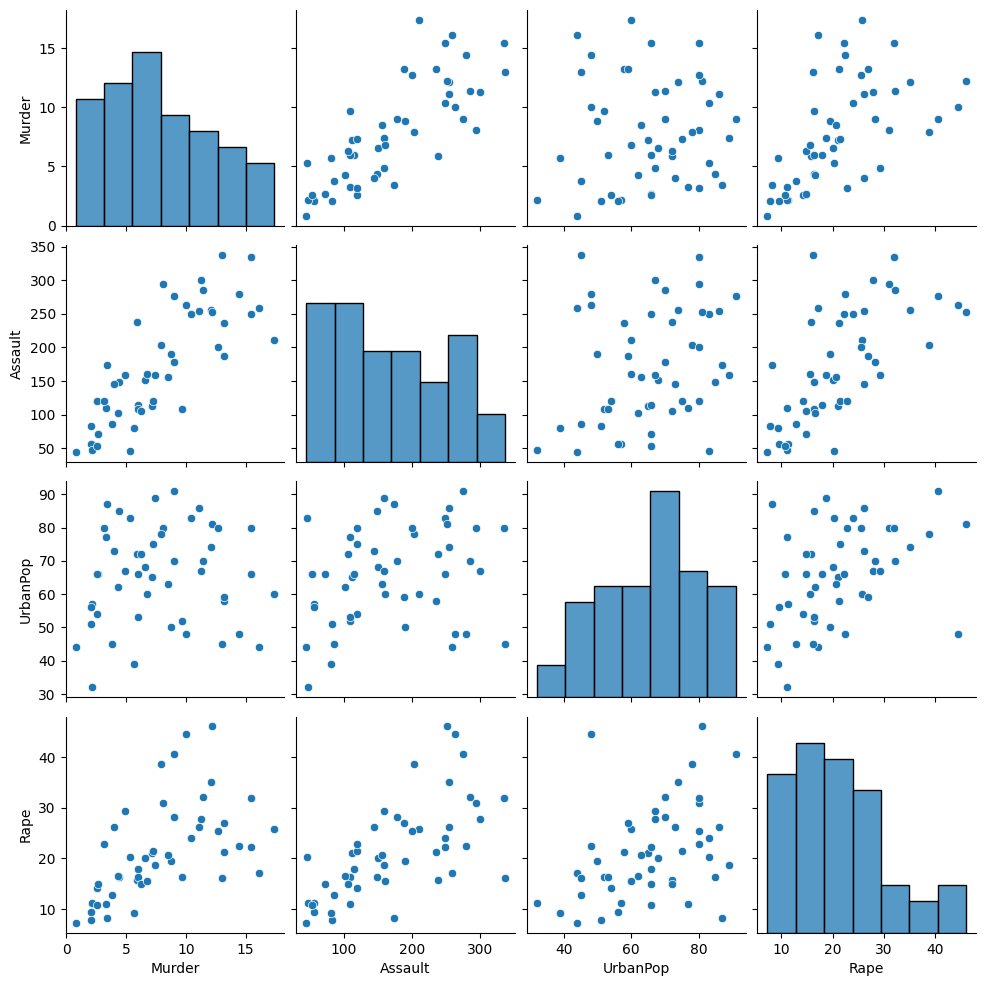

In [41]:
sns.pairplot(crime)

plt.show()

In [42]:
crime.isnull().sum()

Unnamed: 0    0
Murder        0
Assault       0
UrbanPop      0
Rape          0
dtype: int64

In [43]:
X = crime.iloc[:,1:]

In [44]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [45]:
wcss = []

for i in range(1,11):

    model = KMeans(
        n_clusters=i,
        random_state=42
    )

    model.fit(X_scaled)

    wcss.append(model.inertia_)

C:\Users\NARENDRA\anaconda3\envs\AI\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\NARENDRA\anaconda3\envs\AI\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\NARENDRA\anaconda3\envs\AI\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\NARENDRA\anaconda3\envs\AI\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMe

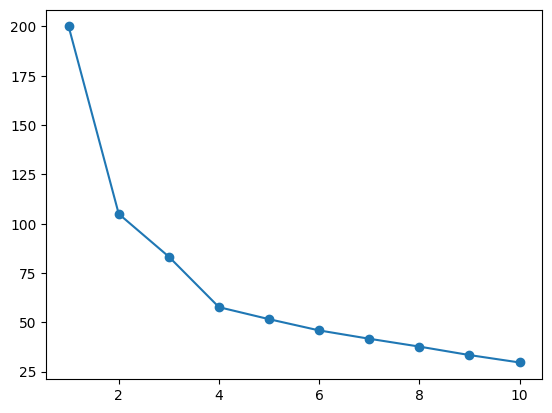

In [46]:
plt.plot(
    range(1,11),
    wcss,
    marker="o"
)

plt.show()

In [47]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

crime["Cluster"] = kmeans.fit_predict(
    X_scaled
)

C:\Users\NARENDRA\anaconda3\envs\AI\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [48]:
crime["Cluster"].value_counts()

Cluster
3    17
0    13
2    12
1     8
Name: count, dtype: int64

In [49]:
silhouette_score(
    X_scaled,
    crime["Cluster"]
)

0.3441080718209351

In [50]:
linkage_matrix = linkage(
    X_scaled,
    method="ward"
)

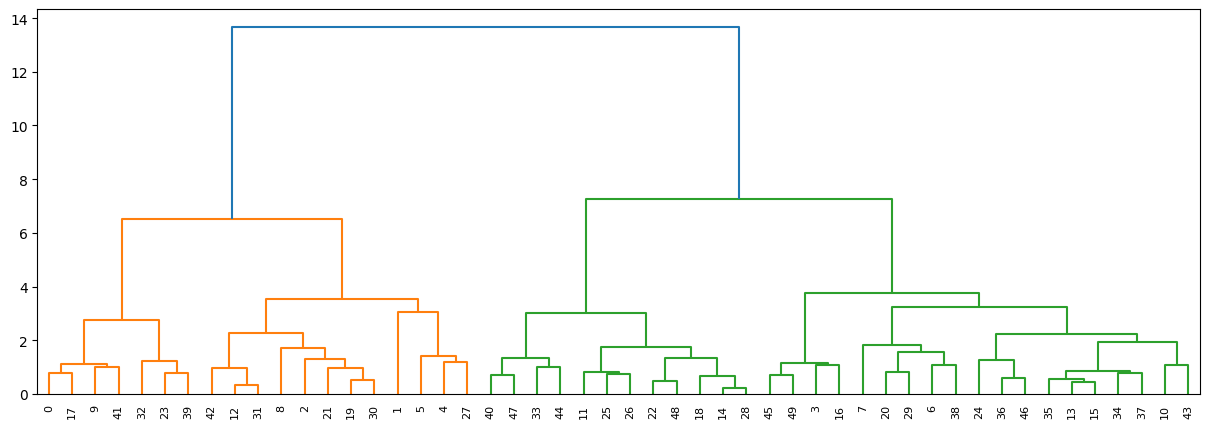

In [51]:
plt.figure(figsize=(15,5))

dendrogram(linkage_matrix)

plt.show()

In [52]:
crime["Hierarchical"] = fcluster(
    linkage_matrix,
    4,
    criterion="maxclust"
)

In [53]:
crime["Hierarchical"].value_counts()

Hierarchical
4    19
2    12
3    12
1     7
Name: count, dtype: int64

In [54]:
crime.groupby(
    "Cluster"
).mean(numeric_only=True)

,Murder,Assault,UrbanPop,Rape,Hierarchical
Cluster,,,,,
0,3.600000,78.538462,52.076923,12.176923,3.076923
1,13.937500,243.625000,53.750000,21.412500,1.375000
2,10.966667,264.000000,76.500000,33.608333,2.000000
3,5.852941,141.176471,73.647059,19.335294,4.000000


In [55]:
print("""
Cluster 0 : Low Crime States

Cluster 1 : Moderate Crime States

Cluster 2 : High Crime States

Cluster 3 : Very High Crime States
""")


Cluster 0 : Low Crime States

Cluster 1 : Moderate Crime States

Cluster 2 : High Crime States

Cluster 3 : Very High Crime States

